# (GQA) Grouped Query Attention

![GQA Diagram](../showcase_images/GQA.png)

**From Llama 3 paper:** 
- "We use grouped query attention ([GQA; Ainslie et al. (2023)](https://arxiv.org/abs/2305.13245)) with $\mathbf{8}$ **key-value heads** to improve inference speed and to reduce the size of **key-value caches** during decoding."
- "We use an attention mask that prevents self-attention between different documents within the same sequence. We find that this change had limited impact during in standard pre-training, but find it to be important in continued pre-training on very long sequences."


**From GQA paper:**

![GQA vs others Diagram](../showcase_images/GQA_vs.png)

In [32]:
import EasyJupyter
import torch
import torch.nn as nn
import torch.nn.functional as F
from model.RoPE import apply_rotary_pos_emb

In [33]:
from typing import TYPE_CHECKING

if TYPE_CHECKING:
    from llama_config import BaseConfig

In [34]:
class GroupedQueryAttention(nn.Module):
    def __init__(self, cfg: BaseConfig):
        """
        (GQA) group query attention.
        """
        super().__init__()
        self.cfg = cfg

        self.attn_heads = cfg.attn_heads
        self.num_kv_heads = cfg.num_kv_heads

        # Determine how many Query heads share a single KV head, e.g., 32/8 = 4.
        self.num_groups = self.attn_heads // self.num_kv_heads
        self.head_dim = cfg.d_model // self.attn_heads

        # Q Projection
        self.wq = nn.Linear(cfg.d_model, self.attn_heads * self.head_dim, bias=False)

        # K and V Projections
        self.wk = nn.Linear(cfg.d_model, self.num_kv_heads * self.head_dim, bias=False)
        self.wv = nn.Linear(cfg.d_model, self.num_kv_heads * self.head_dim, bias=False)

        # Final output projection back to d_model
        self.w_out = nn.Linear(
            self.attn_heads * self.head_dim * self.head_dim, bias=False
        )

    def forward(
        self, x: torch.Tensor, freqs_cis: torch.Tensor, mask: torch.Tensor = None
    ):
        """
        Args:
            x: The input sequence.
            freqs_cis: The precomputed frequencies for RoPE.
            mask: This is a combined mask that contains the causal mask which prevents tokens from attending to future tokens, and the document mask which prevents a token in Doc A from attending to tokens in other documents.
                - Paper mentioned: "We use an attention mask that prevents self-attention between different documents within the same sequence. We find that this change had limited impact during in standard pre-training, but find it to be important in continued pre-training on very long sequences."
        """
        batch_size, seq_len, _ = x.shape

        # Linear Projection
        q = self.wq(x)
        k = self.wk(x)
        v = self.wv(x)

        # Reshape into discrete heads
        q = q.view(batch_size, seq_len, self.attn_heads, self.head_dim)

        # K & V have different shapes than Q
        k = k.view(batch_size, seq_len, self.num_kv_heads, self.head_dim)
        v = v.view(batch_size, seq_len, self.num_kv_heads, self.head_dim)

        # === Apply RoPE ===
        q, k = apply_rotary_pos_emb(q, k, freqs_cis)

        # Transpose dimension for attention math
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        # Broadcast  K and V to match Q shape
        # K shape goes from (batch, 8, seq_len, head_dim) -> (batch, 32, seq_len, head_dim)
        k = torch.repeat_interleave(k, repeats=self.num_groups, dim=1)
        v = torch.repeat_interleave(v, repeats=self.num_groups, dim=1)

        # === Scaled Dot Product Attention
        # is_causal=True automatically handles the causal masking required during pre-training.
        out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask, is_causal=True)

        # Recombine heads and apply final projection
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, -1)

        return self.w_out(out)

In [ ]:
def create_causal_doc_mask(cfg: BaseConfig, token_ids: torch.Tensor) -> torch.Tensor:
    """
    Generates a combined causal and document mask.
        - The causal mask prevents tokens from attending to future tokens.
        - The document mask prevents tokens from Doc A from attending to tokens in Doc B. As defined in the Llama 3 paper: "We use an attention mask that prevents self-attention between different documents within the same sequence. We find that this change had limited impact during in standard pre-training, but find it to be important in continued pre-training on very long sequences."

    Args:
        token_ids: A 2D tensor of shape (batch_size, seq_len) containing token IDs.
    """
    batch_size, seq_len = token_ids.shape

    # === Create the causal mask ===
    causal_mask = torch.triu(
        torch.full((seq_len, seq_len), float("-inf"), device=cfg.device),
        diagonal=1,
    )

    causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)

    # === Create the document mask ===
    # identify the document boundaries
    eod_mask = token_ids == cfg.special_tokens["doc_end_token"]["ID"]

    # Calculate a unique document ID for every token
    #   Tokens at pos N, D1, D1, D1, doc_end_token, D2, D2, ...
    #   doc_ids result: 1, 1, 1, 2, 2, 2, ...
    doc_ids = torch.cumsum(eod_mask.to(torch.long), dim=1) - eod_mask.to(torch.long)

    doc_mask = (doc_ids.unsqueeze(1) != doc_ids.unsqueeze(2))

    # Fill prohibited positions with -inf
    document_blocker = torch.zeros((batch_size, 1, seq_len, seq_len), device=cfg.device)
    document_blocker = document_blocker.masked_fill(doc_mask, -float("inf"))

    # === Combine the causal and document masks ===
    # The combined_mask will be -inf if a position is in the future OR in a different document.
    combined_mask = causal_mask + document_blocker
    return combined_mask

In [52]:
# @i-c
# TEST
import matplotlib.pyplot as plt
from llama_config import BaseConfig

cfg = BaseConfig()
seq_len = 24
batch_size = 1

# Create mock token IDs with known document boundaries
# The 2 is the doc_end_token
token_ids = torch.tensor(
    [
        [1, 1, 1, 1, 2,  # Doc 1 is 5 tokens long
        1, 1, 1, 1, 1, 1, 1, 1, 1, 2,  # Doc 2 is 10 tokens long
        1, 1, 1, 1, 1, 1, 1, 1, 2]  # Doc 3 is 9 tokens long
    ], device=cfg.device
)


Project Root: /Users/tonyavis/Main/AI_projects_and_res/How_to_build_an_LLM


In [53]:
# @i-c
token_ids = token_ids.view(batch_size, seq_len)
f"Token IDs shape: { token_ids.shape}"

'Token IDs shape: torch.Size([1, 24])'

In [54]:
# @i-c
# Test 1: Generate the combined causal and document mask
mask = create_causal_doc_mask(cfg, token_ids)
f"Generated mask shape: {mask.shape}"

'Generated mask shape: torch.Size([1, 1, 24, 24])'

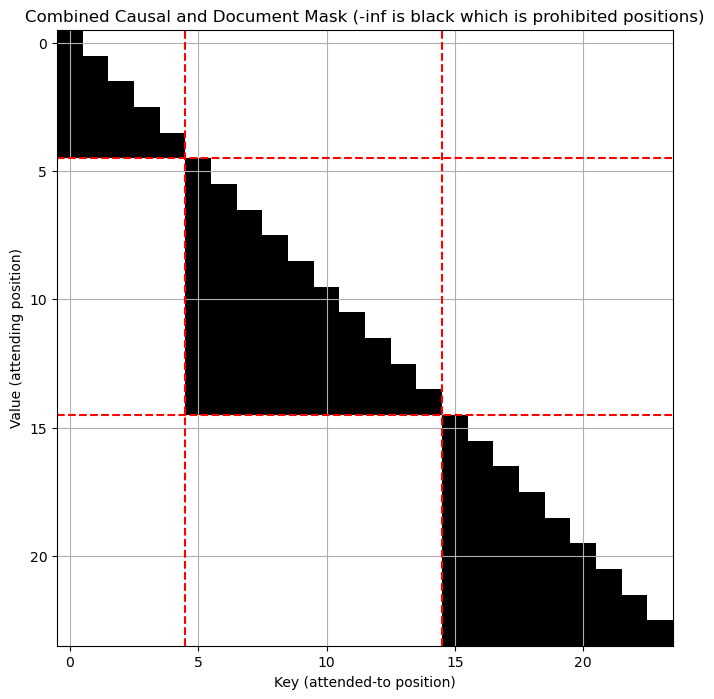

In [ ]:
# @i-c
# Visualize
plot_mask = mask[0,0].clone()
plot_mask[plot_mask == float("-inf")] = 1.0
plt.figure(figsize=(10, 8))
plt.imshow(plot_mask.cpu().numpy(), cmap="grey", interpolation="nearest")
plt.title("Combined Causal and Document Mask (-inf is black which is prohibited positions)")
plt.xlabel("Key (attended-to position)")
plt.ylabel("Value (attending position)")

# Annotate the document boundaries
plt.axhline(y= 4.5, color="red", linestyle="--")
plt.axvline(x= 4.5, color="red", linestyle="--")
plt.axhline(y= 14.5, color="red", linestyle="--")
plt.axvline(x= 14.5, color="red", linestyle="--")
plt.grid(True)
plt.show()
#TODO explain this graph

In [62]:
# @i-c
# test that the standard causal mask is still blocked
assert mask[0, 0, 0, 10] == float("-inf"), "Future tokens are not blocked"

In [63]:
# @i-c
# Test that cross-document attention is blocked
assert mask[0, 0, 10, 1] == float("-inf"), "Attention from Doc 2 to Doc 1 is not blocked"

In [64]:
# @i-c
# Test that internal-document attention is allowed
# Token 10 (Doc 2) attending to Token 6 (Doc 2)
assert mask[0, 0, 10, 6] == 0.0, "Internal-document attention is incorrectly blocked."